## Hypothesis: Sentiment as a lagging indicator to price movement

**Theory:** Markets move independent of news; news reacts. Sentiment (as measured from news) is a *lagging* indicator of price movement rather than a leading one — price moves first, then coverage and tone follow.

## Research question

Does **sentiment lag returns**? If so, we expect:
- Returns at time *t* (or t−1) to be associated with sentiment at *t* or t+1 (news reacts to the move).
- Weak or no predictive power of sentiment at *t* for returns at t+1 (news does not drive the move).

## Testable implications

1. **Lag correlation:** Sentiment (e.g. daily average) at date *t* is more strongly correlated with returns on *t* or *t−1* than with returns on *t+1*.
2. **Predictive regression:** Returns at t (or t−1) help predict sentiment at t (or t+1); sentiment at t does not (or weakly) predict returns at t+1.

## Assumptions

- **Data:** Join table (article_date → price_date = next trading day); use daily aggregates by (article_date or price_date) and ticker.
- **Aggregation:** Daily average sentiment (and optionally dispersion) per ticker; daily returns from OHLCV.
- **Filtering:** Same as project (e.g. minimum ticker coverage, date window from `msa.utils.vars`).
- **Causality:** We do not claim causation; we test lag/lead patterns consistent with "markets move, news reacts."

## Data Loading (minimal)

Load only the essential data needed for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from msa.utils.paths import get_joined_dataset, get_processed_data_path

# Load join table (article_date t -> price_date t+1, with sentiment and next_* prices)
INPUT_PATH = get_joined_dataset()
df = pd.read_csv(INPUT_PATH)
df["article_date"] = pd.to_datetime(df["article_date"], errors="coerce")
df["price_date"] = pd.to_datetime(df["price_date"], errors="coerce")

print(f"Loaded {len(df):,} rows from {INPUT_PATH.name}")
df.head()

Loaded 89,405 rows from gdelt_ohlcv_join.csv


,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_confidence,sentiment_label,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.815164,0.877368,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.927444,0.938555,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,-0.010950,0.934771,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
3,2024-02-08 01:15:00+00:00,https://invezz.com/news/2024/02/07/disney-q1-e...,Disney Q1 earnings : dividend increased as DTC...,English,invezz.com,https://invezz.com/wp-content/uploads/2022/11/...,Apple,AAPL,2024-02-08,0.838071,0.908904,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
4,2024-02-08 01:15:00+00:00,https://www.nbcnewyork.com/news/business/money...,"Jim Cramer says recent moves in Apple , Chipot...",English,nbcnewyork.com,https://media.nbcnewyork.com/2023/11/107113454...,Apple,AAPL,2024-02-08,-0.320946,0.543592,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


# Data Filtering & Preparation

Apply filters and prepare data with clear tracking of each step.

In [2]:
from msa.utils.vars import WINDOW_START, WINDOW_END

print("="*70)
print("DATA FILTERING PIPELINE")
print("="*70)

print(f"\n1. Initial dataset: {len(df):,} rows")

# Restrict to project window (price_date = day we have returns)
df_filtered = df[
    (df["price_date"].dt.normalize() >= pd.Timestamp(WINDOW_START))
    & (df["price_date"].dt.normalize() <= pd.Timestamp(WINDOW_END))
].copy()
print(f"2. After date window ({WINDOW_START} to {WINDOW_END}): {len(df_filtered):,} rows")

# Require sentiment
df_filtered = df_filtered.dropna(subset=["sentiment_score"])
print(f"3. With non-null sentiment: {len(df_filtered):,} rows")

print("\n" + "="*70)

DATA FILTERING PIPELINE

1. Initial dataset: 89,405 rows
2. After date window (2024-02-23 to 2026-02-23): 88,851 rows
3. With non-null sentiment: 88,851 rows



# Calculations

Build daily sentiment and returns by (date, ticker); create lead/lag return series to test whether sentiment is more aligned with same-day or prior-day returns (lagging) vs next-day returns (leading).

In [3]:
# Daily aggregates: sentiment and returns by (price_date, ticker)
# Join is article_date t -> price_date t+1; so article_date aligns with "news day", price_date with "next day price".
# For lag test: we want return on day d and sentiment that could react to it (e.g. same day or next day news).

daily_sent = (
    df_filtered.groupby(["price_date", "ticker"], as_index=False)
    .agg(sentiment_mean=("sentiment_score", "mean"), sentiment_count=("url", "count"))
)
daily_sent = daily_sent.rename(columns={"price_date": "date"})

# Returns: need daily close-to-close return per ticker (from join we have next_open, next_close, etc. per article)
# Build a single return per (date, ticker) from the join (e.g. next_close at t, next_close at t-1 for return_t)
# Simpler: load prices or compute returns from join by grouping by (price_date, ticker) and taking first next_close per day, then pct_change
returns = (
    df_filtered.groupby(["price_date", "ticker"], as_index=False)
    .agg(close=("next_close", "first"), open_=("next_open", "first"))
)
returns = returns.rename(columns={"price_date": "date"})
returns = returns.sort_values(["ticker", "date"]).reset_index(drop=True)
returns["return_1d"] = returns.groupby("ticker")["close"].pct_change()

# Merge sentiment and returns on (date, ticker)
merged = daily_sent.merge(
    returns[["date", "ticker", "return_1d"]],
    on=["date", "ticker"],
    how="inner",
)
merged = merged.dropna(subset=["return_1d", "sentiment_mean"])
merged["date"] = pd.to_datetime(merged["date"]).dt.normalize()

# Lead/lag: create return at t, t-1, t+1 (shift within ticker)
merged = merged.sort_values(["ticker", "date"]).reset_index(drop=True)
merged["return_same"] = merged["return_1d"]
merged["return_lag1"] = merged.groupby("ticker")["return_1d"].shift(-1)   # next day return (sentiment "predicts" this?)
merged["return_lead1"] = merged.groupby("ticker")["return_1d"].shift(1)   # previous day return (sentiment "reacts" to this?)

print("Daily (date, ticker) merged rows:", len(merged))
merged.head(10)

Daily (date, ticker) merged rows: 1372


,date,ticker,sentiment_mean,sentiment_count,return_1d,return_same,return_lag1,return_lead1
0,2024-03-04,AAPL,-0.123154,58,-0.033451,-0.033451,-0.028441,NaN
1,2024-03-05,AAPL,-0.133183,95,-0.028441,-0.028441,0.015460,-0.033451
2,2024-03-11,AAPL,-0.070435,145,0.015460,0.015460,0.019276,-0.028441
3,2024-03-19,AAPL,-0.042764,129,0.019276,0.019276,0.014709,0.015460
4,2024-03-20,AAPL,-0.078645,52,0.014709,0.014709,-0.043768,0.019276
5,2024-03-25,AAPL,-0.282020,175,-0.043768,-0.043768,-0.011882,0.014709
6,2024-04-04,AAPL,-0.116154,70,-0.011882,-0.011882,-0.002192,-0.043768
7,2024-04-08,AAPL,0.160586,23,-0.002192,-0.002192,0.007243,-0.011882
8,2024-04-09,AAPL,0.090067,24,0.007243,0.007243,-0.011139,-0.002192
9,2024-04-10,AAPL,0.707314,2,-0.011139,-0.011139,0.043271,0.007243


# Test

Evaluate whether sentiment lags returns: compare correlation of sentiment with same-day, prior-day, and next-day returns; optionally run predictive regressions (return → sentiment vs sentiment → return).

## Correlation?

In [4]:
# Lag test: correlation of sentiment_t with return_same, return_lead1 (prior day), return_lag1 (next day)
# If sentiment lags price: corr(sentiment, return_lead1) >= corr(sentiment, return_same) or corr(sentiment, return_lag1)
drop_na = merged[["sentiment_mean", "return_same", "return_lead1", "return_lag1"]].dropna()
corrs = drop_na.corr().loc["sentiment_mean", ["return_same", "return_lead1", "return_lag1"]]
print("Correlation of daily sentiment with:")
print(corrs.to_string())
print("\nInterpretation: If sentiment lags price, we expect stronger correlation with return_lead1 (yesterday's return) than with return_lag1 (tomorrow's return).")

Correlation of daily sentiment with:
return_same     0.040718
return_lead1    0.091646
return_lag1    -0.013627

Interpretation: If sentiment lags price, we expect stronger correlation with return_lead1 (yesterday's return) than with return_lag1 (tomorrow's return).


## Predictive regression

Does prior-day return predict today's sentiment (lag)? Does today's sentiment predict next-day return (lead)? Fit simple OLS; compare R² or coefficients.

In [5]:
# Example: return_lead1 (yesterday return) -> sentiment_mean (today); sentiment_mean (today) -> return_lag1 (tomorrow)
# If sentiment lags: return_lead1 should explain sentiment_mean better than sentiment_mean explains return_lag1.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_lag = merged[["return_lead1"]].dropna()
y_sent = merged.loc[X_lag.index, "sentiment_mean"]
X_lag = X_lag.dropna()
y_sent = y_sent.loc[X_lag.index]
m_lag = LinearRegression().fit(X_lag, y_sent)
r2_lag = r2_score(y_sent, m_lag.predict(X_lag))

X_lead = merged[["sentiment_mean"]].dropna()
y_ret = merged.loc[X_lead.index, "return_lag1"]
X_lead = X_lead.dropna()
y_ret = y_ret.loc[X_lead.index].dropna()
X_lead = X_lead.loc[y_ret.index]
m_lead = LinearRegression().fit(X_lead, y_ret)
r2_lead = r2_score(y_ret, m_lead.predict(X_lead))

print("R² return_lead1 -> sentiment_mean (lag):", round(r2_lag, 4))
print("R² sentiment_mean -> return_lag1 (lead):", round(r2_lead, 4))
print("Lag story supported if R²(return->sentiment) >= R²(sentiment->return).")

R² return_lead1 -> sentiment_mean (lag): 0.0084
R² sentiment_mean -> return_lag1 (lead): 0.0002
Lag story supported if R²(return->sentiment) >= R²(sentiment->return).


## Visualization: prior-day return vs sentiment

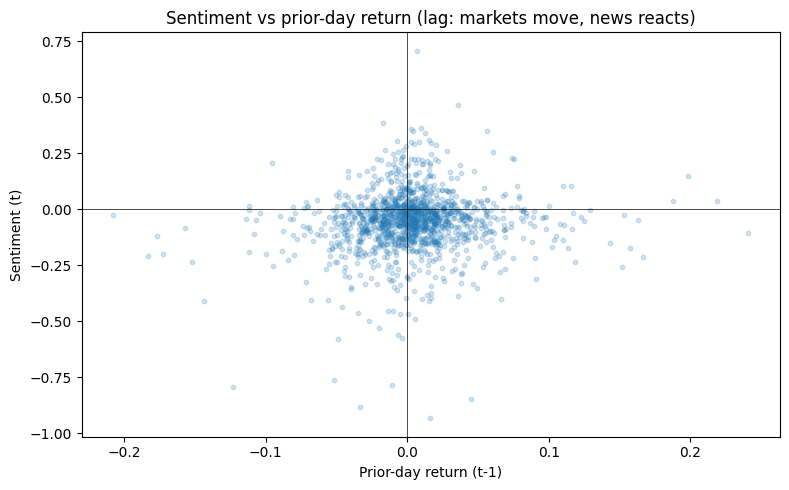

In [6]:
# Scatter: prior-day return (x) vs same-day sentiment (y) — expect positive if news reacts to moves
fig, ax = plt.subplots(figsize=(8, 5))
v = merged[["return_lead1", "sentiment_mean"]].dropna()
ax.scatter(v["return_lead1"], v["sentiment_mean"], alpha=0.2, s=10)
ax.set_xlabel("Prior-day return (t-1)")
ax.set_ylabel("Sentiment (t)")
ax.set_title("Sentiment vs prior-day return (lag: markets move, news reacts)")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
plt.tight_layout()
plt.show()


## Conclusion

### Answer to hypothesis (sentiment as lagging indicator)

- **Weak Support**: Correlation is *very weak* (.09); however, the slight negative correlation with `return_lag1` points to possible validity in the theory that sentiment is lagging returns.
- Prior day returns (`return_lead1`) have, relatively speaking, the highest positive link to sentiment and `return_lag1` have the weakest/slightly negative link, implying pattern correctness (sentiment lags returns)

## Next Steps

- Focus on extreme days (instead of averages)

## Follow-up

- Is aggregation masking signal in tail (extreme) events?

In [7]:
# Extreme days: split by high/low SENTIMENT, then look at mean RETURN on those days
high_threshold = merged['sentiment_mean'].quantile(0.95)
low_threshold = merged['sentiment_mean'].quantile(0.05)

merged['extreme_positive'] = merged['sentiment_mean'] >= high_threshold
merged['extreme_negative'] = merged['sentiment_mean'] <= low_threshold

# Mean same-day return when sentiment is extreme (daily returns are small, e.g. 0.001 = 0.1%)
mean_positive = merged[merged['extreme_positive']]['return_1d'].mean()
mean_negative = merged[merged['extreme_negative']]['return_1d'].mean()
n_pos = merged['extreme_positive'].sum()
n_neg = merged['extreme_negative'].sum()

# Compare with leading returns
mean_positive_lead = merged[merged['extreme_positive']]['return_lead1'].mean()
mean_negative_lead = merged[merged['extreme_negative']]['return_lead1'].mean()
n_pos_lead = merged['extreme_positive'].sum()
n_neg_lead = merged['extreme_negative'].sum()

# Show as decimal (6 dp) and as percent — :.2f was rounding small returns to 0.00
print("Extreme days for sentiment:")
print(f"Extreme positive sentiment (>= 95th pct): n={n_pos}, mean return = {mean_positive:.6f} ({100*mean_positive:.2f}%)")
print(f"Extreme negative sentiment (<= 5th pct):  n={n_neg}, mean return = {mean_negative:.6f} ({100*mean_negative:.2f}%)")
print("\nExtreme days for leading return:")
print(f"Extreme positive leading return: n={n_pos_lead}, mean return = {mean_positive_lead:.6f} ({100*mean_positive_lead:.2f}%)")
print(f"Extreme negative leading return: n={n_neg_lead}, mean return = {mean_negative_lead:.6f} ({100*mean_negative_lead:.2f}%)")



Extreme days for sentiment:
Extreme positive sentiment (>= 95th pct): n=69, mean return = 0.004320 (0.43%)
Extreme negative sentiment (<= 5th pct):  n=69, mean return = -0.004865 (-0.49%)

Extreme days for leading return:
Extreme positive leading return: n=69, mean return = 0.005420 (0.54%)
Extreme negative leading return: n=69, mean return = -0.005105 (-0.51%)


In [8]:
# Shuffle sentiment labels
shuffled = merged.copy()
shuffled['sentiment_mean'] = np.random.permutation(shuffled['sentiment_mean'])

# Remcompute extremes and results
high_threshold = shuffled['sentiment_mean'].quantile(0.95)
low_threshold = shuffled['sentiment_mean'].quantile(0.05)

shuffled['extreme_positive'] = shuffled['sentiment_mean'] >= high_threshold
shuffled['extreme_negative'] = shuffled['sentiment_mean'] <= low_threshold

mean_positive_shuffled = shuffled[shuffled['extreme_positive']]['return_1d'].mean()
mean_negative_shuffled = shuffled[shuffled['extreme_negative']]['return_1d'].mean()
n_pos_shuffled = shuffled['extreme_positive'].sum()
n_neg_shuffled = shuffled['extreme_negative'].sum()

print("Shuffled sentiment:")
print(f"Extreme positive sentiment (>= 95th pct): n={n_pos_shuffled}, mean return = {mean_positive_shuffled:.6f} ({100*mean_positive_shuffled:.2f}%)")
print(f"Extreme negative sentiment (<= 5th pct):  n={n_neg_shuffled}, mean return = {mean_negative_shuffled:.6f} ({100*mean_negative_shuffled:.2f}%)")







Shuffled sentiment:
Extreme positive sentiment (>= 95th pct): n=69, mean return = 0.001249 (0.12%)
Extreme negative sentiment (<= 5th pct):  n=69, mean return = 0.003711 (0.37%)


 h    n      corr      coef       r2
 2 1358 -0.026025 -0.007598 0.000677
 3 1351 -0.029624 -0.008666 0.000878
 4 1344 -0.008461 -0.002476 0.000072
 5 1337 -0.007062 -0.002064 0.000050


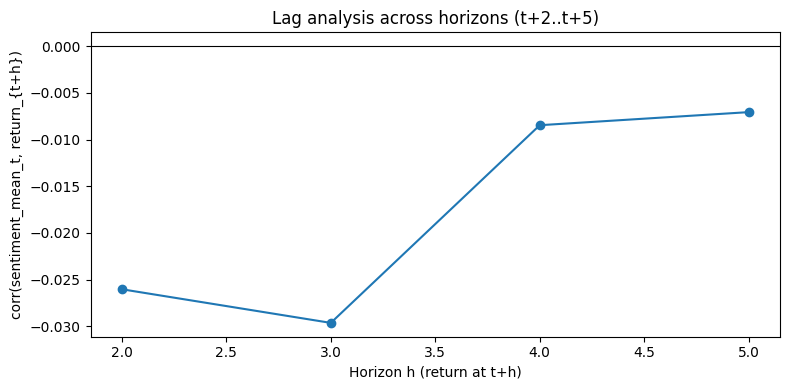

In [9]:
# Lag analysis: does sentiment_t predict returns at t+2..t+5?

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Ensure correct ordering before shifting
_tmp = merged.sort_values(["ticker", "date"]).reset_index(drop=True)

future_horizons = [2, 3, 4, 5]

rows = []
for h in future_horizons:
    # return at time (t+h), aligned with sentiment at time t
    col = f"return_lag{h}"
    _tmp[col] = _tmp.groupby("ticker")["return_1d"].shift(-h)

    v = _tmp[["sentiment_mean", col]].dropna()
    corr = v["sentiment_mean"].corr(v[col])

    # Regression: return_{t+h} ~ sentiment_t
    X = v[["sentiment_mean"]].values
    y = v[col].values
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    coef = float(model.coef_[0])

    rows.append({"h": h, "n": len(v), "corr": corr, "coef": coef, "r2": r2})

res = pd.DataFrame(rows).sort_values("h")
print(res.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

plt.figure(figsize=(8, 4))
plt.plot(res["h"], res["corr"], marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Horizon h (return at t+h)")
plt.ylabel("corr(sentiment_mean_t, return_{t+h})")
plt.title("Lag analysis across horizons (t+2..t+5)")
plt.tight_layout()
plt.show()

## Findings
- Permutation testing suggests that the observed relationship for extreme sentiment is not attributable to random chance, while the positive extreme signal appears partially driven by underlying market drift
- While extreme sentiment events exhibit directional alignment with returns, permutation testing reveals that this event is **asymmetric**.  
- The relationship for negative sentiment is **not** preserved under randomization, suggesting a genuine association with downside movements (positive sentiment effects appear largely explained by underlying market drift).

 h    n  corr_obs   r2_obs  p_abs_corr  p_abs_corr_2000
 2 1358 -0.026025 0.000677    0.316000         0.168500
 3 1351 -0.029624 0.000878    0.250000         0.239500
 4 1344 -0.008461 0.000072    0.764000         0.526000
 5 1337 -0.007062 0.000050    0.818000         0.213500


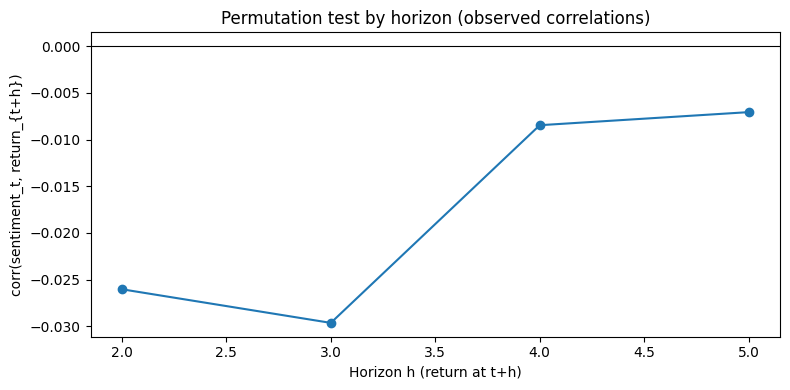

In [10]:
# Permutation test by horizon: how surprising is corr(sentiment_t, return_{t+h})?
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

_tmp = merged.sort_values(["ticker", "date"]).reset_index(drop=True)

future_horizons = [2, 3, 4, 5]

# Shuffle within ticker to preserve per-ticker distribution while breaking alignment
rng = np.random.default_rng(42)

B = 500  # number of permutations; increase to 2000+ for tighter p-values
B2000 = 2000

out_rows = []

# Precompute shifted return columns once
for h in future_horizons:
    _tmp[f"return_lag{h}"] = _tmp.groupby("ticker")["return_1d"].shift(-h)

for h in future_horizons:
    col = f"return_lag{h}"
    v = _tmp[["sentiment_mean", col, "ticker"]].dropna().copy()

    x_obs = v["sentiment_mean"].to_numpy()
    y = v[col].to_numpy()

    # Observed correlation + regression
    corr_obs = float(np.corrcoef(x_obs, y)[0, 1])
    model = LinearRegression().fit(x_obs.reshape(-1, 1), y)
    r2_obs = float(r2_score(y, model.predict(x_obs.reshape(-1, 1))))

    # Permutation distribution for corr
    perm_corrs = np.empty(B, dtype=float)
    # Compute 2000 permutations
    perm_corrs_2000 = np.empty(B2000, dtype=float)


    # Indices per ticker for efficient within-ticker shuffling
    ticker_vals = v["ticker"].to_numpy()
    uniq_tickers = pd.unique(ticker_vals)
    idx_by_t = {t: np.where(ticker_vals == t)[0] for t in uniq_tickers}

    for b in range(B):
        x_perm = x_obs.copy()
        for t, idxs in idx_by_t.items():
            # shuffle sentiment values among rows of the same ticker
            x_perm[idxs] = rng.permutation(x_perm[idxs])

        perm_corrs[b] = float(np.corrcoef(x_perm, y)[0, 1])
        perm_corrs_2000[b] = float(np.corrcoef(x_perm, y)[0, 1])

    # Two-sided empirical p-value based on absolute correlation
    p_abs = float(np.mean(np.abs(perm_corrs) >= abs(corr_obs)))
    p_abs_2000 = float(np.mean(np.abs(perm_corrs_2000) >= abs(corr_obs)))
    out_rows.append({"h": h, "n": len(v), "corr_obs": corr_obs, "r2_obs": r2_obs, "p_abs_corr": p_abs, "p_abs_corr_2000": p_abs_2000})

res = pd.DataFrame(out_rows).sort_values("h")
print(res.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Quick look plot of corr p-values (optional)
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.plot(res["h"], res["corr_obs"], marker="o", label="observed corr")
    plt.axhline(0, color="k", lw=0.8)
    plt.xlabel("Horizon h (return at t+h)")
    plt.ylabel("corr(sentiment_t, return_{t+h})")
    plt.title("Permutation test by horizon (observed correlations)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped:", e)


## Extended lag analysis & aggregation

Aligned with correlation-mapping follow-ups:

- **Longer horizons:** trading-day lags **7, 14, 30** (`sentiment_t` vs `return_{t+h}`), same shift logic as `t+2..t+5`.
- **Weekly panel:** aggregate by **ticker × calendar week** (week-ending `W-SUN`): mean sentiment, compound weekly return; then correlate weekly sentiment with **next-week** return (lead-by-one week).
- **Rolling sentiment:** **5d**, **20d**, and **30d** (trading-day) rolling mean of `sentiment_mean`; correlate with `return_{t+h}` for selected `h` (e.g. 1, 5, 10) to see if smoother tone has more signal.
- **Volatility:** **Forward realized vol** = sample std of daily `return_1d` over the **next** `h` trading days (per ticker); correlate `sentiment_t` with that vol (and optionally `|return_{t+h}|` as a simple point proxy).

*Note:* Sample size drops as `h` grows (end-of-series). Weekly panel has fewer rows than daily.

=== A) Long horizons: sentiment_t vs return_{t+h} ===
 h    n      corr
 7 1323  0.006268
14 1274 -0.012437
30 1162 -0.022645

=== B) sentiment_t vs forward realized vol (std of next h daily returns) ===
 h    n  corr_sent_fwdvol
 7 1323         -0.155119
14 1274         -0.173743
30 1162         -0.131389

=== B') sentiment_t vs |return_{t+h}| ===
 h    n  corr_sent_absret
 7 1323         -0.031435
14 1274         -0.093406
30 1162         -0.017021

=== C) Rolling sentiment vs return_{t+h} ===
   sentiment  h    n      corr
 roll5d_sent  1 1351 -0.027401
 roll5d_sent  5 1323 -0.003878
 roll5d_sent 10 1288 -0.059968
roll20d_sent  1 1302 -0.037543
roll20d_sent  5 1274 -0.036244
roll20d_sent 10 1239 -0.055762
roll30d_sent  1 1267 -0.045907
roll30d_sent  5 1239 -0.048861
roll30d_sent 10 1204 -0.048046

=== D) Weekly: corr(sentiment_w, next_week_return) ===
n_week_rows=558, corr=-0.059946


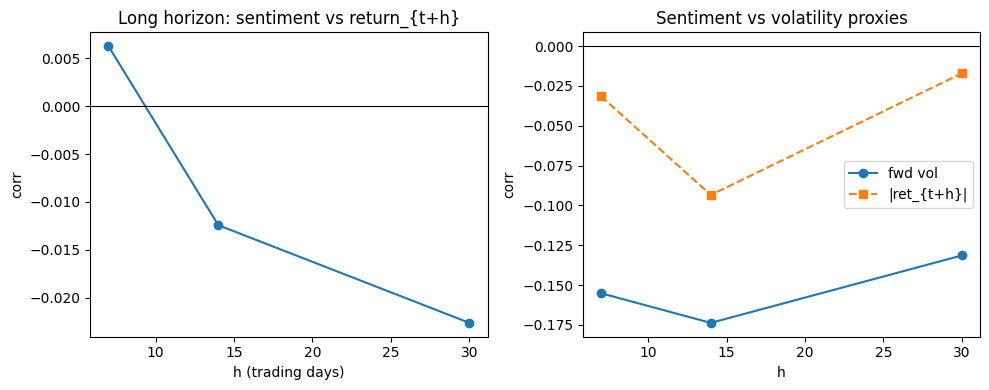

In [11]:
# Extended horizons (7, 14, 30), weekly aggregation, rolling sentiment, sentiment -> vol
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

m = merged.sort_values(["ticker", "date"]).reset_index(drop=True)

# --- A) Long horizons: corr(sentiment_mean_t, return_{t+h}) for h in {7, 14, 30}
long_h = [7, 14, 30]
rows_long = []
for h in long_h:
    col = f"return_lag{h}"
    m[col] = m.groupby("ticker")["return_1d"].shift(-h)
    v = m[["sentiment_mean", col]].dropna()
    rows_long.append({"h": h, "n": len(v), "corr": v["sentiment_mean"].corr(v[col])})
print("=== A) Long horizons: sentiment_t vs return_{t+h} ===")
print(pd.DataFrame(rows_long).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# --- B) Forward realized volatility over next h days (std of daily returns t+1..t+h)
def _forward_std_per_group(s: pd.Series, h: int) -> pd.Series:
    arr = s.to_numpy(dtype=float)
    n = len(arr)
    out = np.full(n, np.nan)
    for i in range(n):
        chunk = arr[i + 1 : i + 1 + h]
        if len(chunk) < h or np.any(np.isnan(chunk)):
            continue
        out[i] = float(np.std(chunk, ddof=1))
    return pd.Series(out, index=s.index)

for h in long_h:
    m[f"fwd_vol_{h}"] = m.groupby("ticker", group_keys=False)["return_1d"].transform(
        lambda s, hh=h: _forward_std_per_group(s, hh)
    )

rows_vol = []
for h in long_h:
    col = f"fwd_vol_{h}"
    v = m[["sentiment_mean", col]].dropna()
    rows_vol.append({"h": h, "n": len(v), "corr_sent_fwdvol": v["sentiment_mean"].corr(v[col])})
print("\n=== B) sentiment_t vs forward realized vol (std of next h daily returns) ===")
print(pd.DataFrame(rows_vol).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Point proxy: |return| at t+h
rows_abs = []
for h in long_h:
    col = f"abs_ret_lag{h}"
    m[col] = m.groupby("ticker")["return_1d"].shift(-h).abs()
    v = m[["sentiment_mean", col]].dropna()
    rows_abs.append({"h": h, "n": len(v), "corr_sent_absret": v["sentiment_mean"].corr(v[col])})
print("\n=== B') sentiment_t vs |return_{t+h}| ===")
print(pd.DataFrame(rows_abs).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# --- C) Rolling sentiment (trading-day windows)
m["sentiment_roll5"] = m.groupby("ticker")["sentiment_mean"].transform(
    lambda s: s.rolling(5, min_periods=3).mean()
)
m["sentiment_roll20"] = m.groupby("ticker")["sentiment_mean"].transform(
    lambda s: s.rolling(20, min_periods=10).mean()
)
m["sentiment_roll30"] = m.groupby("ticker")["sentiment_mean"].transform(
    lambda s: s.rolling(30, min_periods=15).mean()
)

roll_specs = [
    ("sentiment_roll5", "roll5d_sent"),
    ("sentiment_roll20", "roll20d_sent"),
    ("sentiment_roll30", "roll30d_sent"),
]
roll_h = [1, 5, 10]
rows_roll = []
for sent_col, label in roll_specs:
    for h in roll_h:
        rcol = f"_r{h}"
        m[rcol] = m.groupby("ticker")["return_1d"].shift(-h)
        v = m[[sent_col, rcol]].dropna()
        rows_roll.append(
            {
                "sentiment": label,
                "h": h,
                "n": len(v),
                "corr": v[sent_col].corr(v[rcol]),
            }
        )
print("\n=== C) Rolling sentiment vs return_{t+h} ===")
print(pd.DataFrame(rows_roll).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# --- D) Weekly aggregation: mean sentiment & compound return; sentiment_w vs return_{w+1}
mw = m[["date", "ticker", "sentiment_mean", "return_1d"]].copy()
mw["date"] = pd.to_datetime(mw["date"])
wk = (
    mw.groupby(["ticker", pd.Grouper(key="date", freq="W-SUN")], observed=True)
    .agg(
        sentiment_mean_w=("sentiment_mean", "mean"),
        week_return=("return_1d", lambda x: float(np.prod(1.0 + x.to_numpy()) - 1.0)),
        n_days=("return_1d", "count"),
    )
    .reset_index()
)
wk = wk.rename(columns={"date": "week_end"})
wk = wk.sort_values(["ticker", "week_end"]).reset_index(drop=True)
wk["next_week_return"] = wk.groupby("ticker")["week_return"].shift(-1)
v_w = wk[["sentiment_mean_w", "next_week_return"]].dropna()
print("\n=== D) Weekly: corr(sentiment_w, next_week_return) ===")
print(f"n_week_rows={len(v_w)}, corr={v_w['sentiment_mean_w'].corr(v_w['next_week_return']):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pd.DataFrame(rows_long)["h"], pd.DataFrame(rows_long)["corr"], "o-")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("h (trading days)")
axes[0].set_ylabel("corr")
axes[0].set_title("Long horizon: sentiment vs return_{t+h}")

axes[1].plot(pd.DataFrame(rows_vol)["h"], pd.DataFrame(rows_vol)["corr_sent_fwdvol"], "o-", label="fwd vol")
axes[1].plot(pd.DataFrame(rows_abs)["h"], pd.DataFrame(rows_abs)["corr_sent_absret"], "s--", label="|ret_{t+h}|")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("h")
axes[1].set_ylabel("corr")
axes[1].set_title("Sentiment vs volatility proxies")
axes[1].legend()
plt.tight_layout()
plt.show()